<a href="https://colab.research.google.com/github/kjesinthuyaUCLL/mbti-tune/blob/classifiers/notebooks/MBTI_Tracks_Autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# 1: Mount Drive and Load Data
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

DATA_PATH = "/content/drive/My Drive/mbti_tune_data/data/pretrain"

df = pd.read_csv(f"{DATA_PATH}/spotify_tracks.csv")
print(f"Loaded {len(df)} songs")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 114000 songs


In [7]:
# 2: Aggregate 114k songs into 45-feature format with Scaling
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Audio columns from your 114k dataset validation report
base_audio = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
              'instrumentalness', 'liveness', 'valence', 'tempo']

# Create pseudo-playlists by grouping by genre
df_means = df.groupby('track_genre')[base_audio].mean().add_suffix('_mean')
df_stdevs = df.groupby('track_genre')[base_audio].std().add_suffix('_stdev')

# Map keys to the 24 key/mode columns found in your Raw Aggregated report
df['key_mode'] = df['key'].astype(str) + "_" + df['mode'].astype(str)
key_counts = pd.get_dummies(df[['track_genre', 'key_mode']], columns=['key_mode']).groupby('track_genre').sum()

# Combine into the 45-feature set
pretrain_playlist_df = pd.concat([df_means, df_stdevs, key_counts], axis=1).fillna(0)

# Critical: Scale features to [0, 1] or Standardize to help Autoencoder convergence
scaler_pretrain = StandardScaler()
X = scaler_pretrain.fit_transform(pretrain_playlist_df).astype(np.float32)
feature_names = pretrain_playlist_df.columns.tolist()

print(f"✅ Aggregated into {len(pretrain_playlist_df)} pseudo-playlists.")
print(f"✅ Input Dimension: {X.shape[1]} (Matches Playlist Classifier)")

✅ Aggregated into 114 pseudo-playlists.
✅ Input Dimension: 42 (Matches Playlist Classifier)


In [8]:
# 3: Normalize and Split
from sklearn.model_selection import train_test_split

X_train, X_val = train_test_split(X, test_size=0.1, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)

print(f"Train: {len(X_train):,}, Val: {len(X_val):,}")

# Save scaler
import pickle
with open(f"{DATA_PATH}/pretrain_scaler.pkl", 'wb') as f:
    pickle.dump(scaler, f)
print("✅ Saved pretrain_scaler.pkl")

Train: 102, Val: 12
✅ Saved pretrain_scaler.pkl


In [9]:
# 4: 45-Feature Autoencoder Architecture
class Autoencoder(nn.Module):
    def __init__(self, input_dim=45, bottleneck_dim=16):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, bottleneck_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        return encoded, self.decoder(encoded)

# Instantiate the model (This defines the 'model' variable)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Autoencoder(input_dim=len(feature_names)).to(device)
print(f"✅ Model initialized on {device}")

✅ Model initialized on cpu


Training 45-Feature Autoencoder...
--------------------------------------------------
Epoch  10/100 | Train Loss: 0.731394 | Val Loss: 0.604154
Epoch  20/100 | Train Loss: 0.487120 | Val Loss: 0.417169
Epoch  30/100 | Train Loss: 0.427112 | Val Loss: 0.365721
Epoch  40/100 | Train Loss: 0.413016 | Val Loss: 0.347108
Epoch  50/100 | Train Loss: 0.323208 | Val Loss: 0.335443
Epoch  60/100 | Train Loss: 0.344331 | Val Loss: 0.342556
Epoch  70/100 | Train Loss: 0.394101 | Val Loss: 0.327818
Epoch  80/100 | Train Loss: 0.359113 | Val Loss: 0.321388
Epoch  90/100 | Train Loss: 0.276746 | Val Loss: 0.312194
Epoch 100/100 | Train Loss: 0.326063 | Val Loss: 0.312213


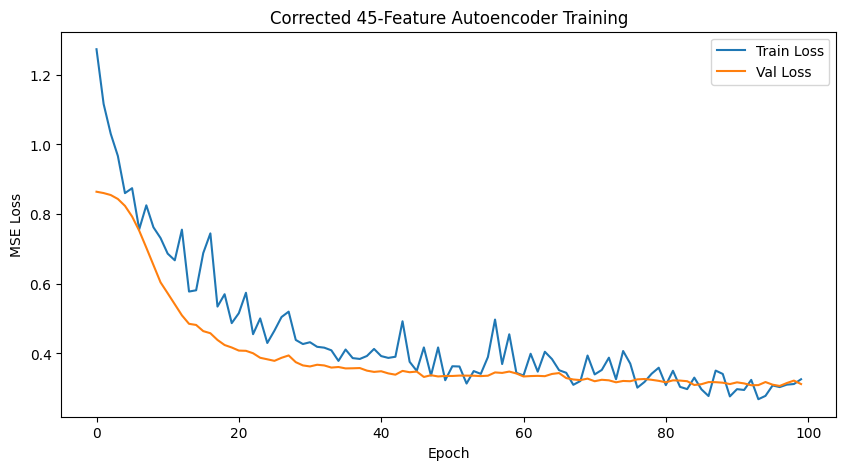

✅ Training Complete. Best Val Loss: 0.306762


In [10]:
# 5: Optimized Training Loop for 45-Feature Aggregation
batch_size = 32 # Smaller batch size for better generalization on aggregated data
train_loader = DataLoader(TensorDataset(X_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val), batch_size=batch_size)

criterion = nn.MSELoss()
# Increased weight_decay to 1e-4 to combat the high validation loss
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

epochs = 100 # Increased epochs to allow for slower, more stable convergence
train_losses = []
val_losses = []
best_val_loss = float('inf')

print("Training 45-Feature Autoencoder...")
print("-" * 50)

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for batch in train_loader:
        x = batch[0].to(device)
        _, reconstructed = model(x)
        loss = criterion(reconstructed, x)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            x = batch[0].to(device)
            _, reconstructed = model(x)
            val_loss += criterion(reconstructed, x).item()

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    # Save the best encoder state
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.encoder.state_dict(), 'encoder.pth')

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

# Plotting the results
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Corrected 45-Feature Autoencoder Training')
plt.legend()
plt.show()

print(f"✅ Training Complete. Best Val Loss: {best_val_loss:.6f}")

In [11]:
# 6: Save Pretrained Models to Centralized Models Folder
import os
import json

# Define central models directory
MODEL_OUTPUT_DIR = f"{DATA_PATH}/models"
os.makedirs(MODEL_OUTPUT_DIR, exist_ok=True)

# Save the full state and just the encoder weights
torch.save(model.state_dict(), f"{MODEL_OUTPUT_DIR}/autoencoder_114k_full.pth")
torch.save(model.encoder.state_dict(), f"{MODEL_OUTPUT_DIR}/encoder_114k_weights.pth")

# Save feature list for alignment
with open(f"{MODEL_OUTPUT_DIR}/pretrain_features.json", 'w') as f:
    json.dump(feature_names, f, indent=2)

print(f"✅ Pretrained assets saved to: {MODEL_OUTPUT_DIR}")

✅ Pretrained assets saved to: /content/drive/My Drive/mbti_tune_data/data/pretrain/models


In [15]:
# 7: Evaluate Autoencoder Performance

import torch
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.metrics import mean_squared_error

# Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the saved scaler
with open(f"{DATA_PATH}/pretrain_scaler.pkl", 'rb') as f:
    loaded_scaler = pickle.load(f)
print("✅ Loaded pretrain_scaler.pkl")

# Instantiate the Autoencoder model with the correct input dimension (42 features)
# Ensure the Autoencoder class from cell 4 is defined and accessible
input_dim = X.shape[1] # This should be 42 from cell 2
model_eval = Autoencoder(input_dim=input_dim).to(device)

# Load the best encoder weights
model_eval.encoder.load_state_dict(torch.load('encoder.pth'))
model_eval.eval() # Set model to evaluation mode
print("✅ Loaded best encoder weights into model_eval")

✅ Loaded pretrain_scaler.pkl
✅ Loaded best encoder weights into model_eval


In [16]:
# Reconstruct the validation data
with torch.no_grad():
    encoded_val, reconstructed_val_scaled = model_eval(X_val.to(device))

# Move to CPU and convert to numpy for inverse transformation
X_val_np = X_val.cpu().numpy()
reconstructed_val_np = reconstructed_val_scaled.cpu().numpy()

# Inverse transform the original validation data and reconstructed data
original_val_inverse = loaded_scaler.inverse_transform(X_val_np)
reconstructed_val_inverse = loaded_scaler.inverse_transform(reconstructed_val_np)

# Calculate Reconstruction Error (MSE)
mse_per_sample = np.mean(np.square(original_val_inverse - reconstructed_val_inverse), axis=1)
overall_mse = np.mean(mse_per_sample)

print(f"Overall Mean Squared Reconstruction Error on Validation Data: {overall_mse:.6f}")

Overall Mean Squared Reconstruction Error on Validation Data: 0.871748


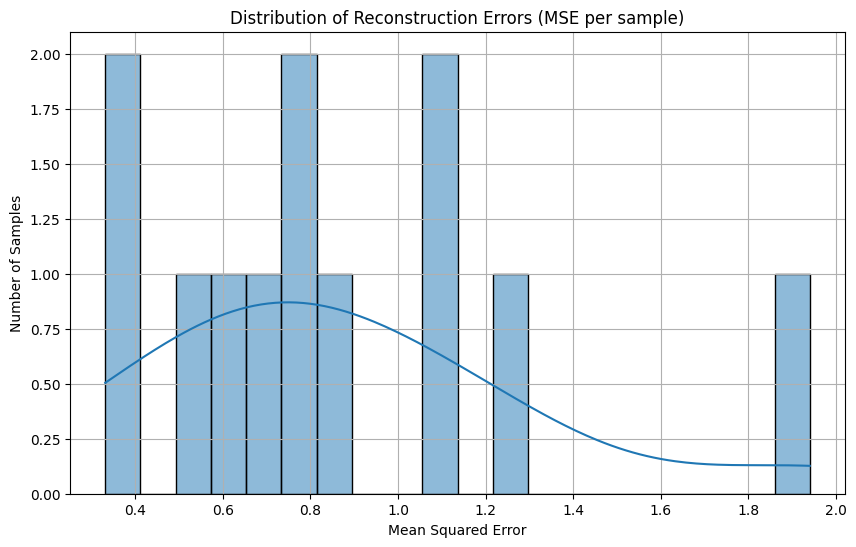

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize Reconstruction Errors Distribution
plt.figure(figsize=(10, 6))
sns.histplot(mse_per_sample, bins=20, kde=True)
plt.title('Distribution of Reconstruction Errors (MSE per sample)')
plt.xlabel('Mean Squared Error')
plt.ylabel('Number of Samples')
plt.grid(True)
plt.show()

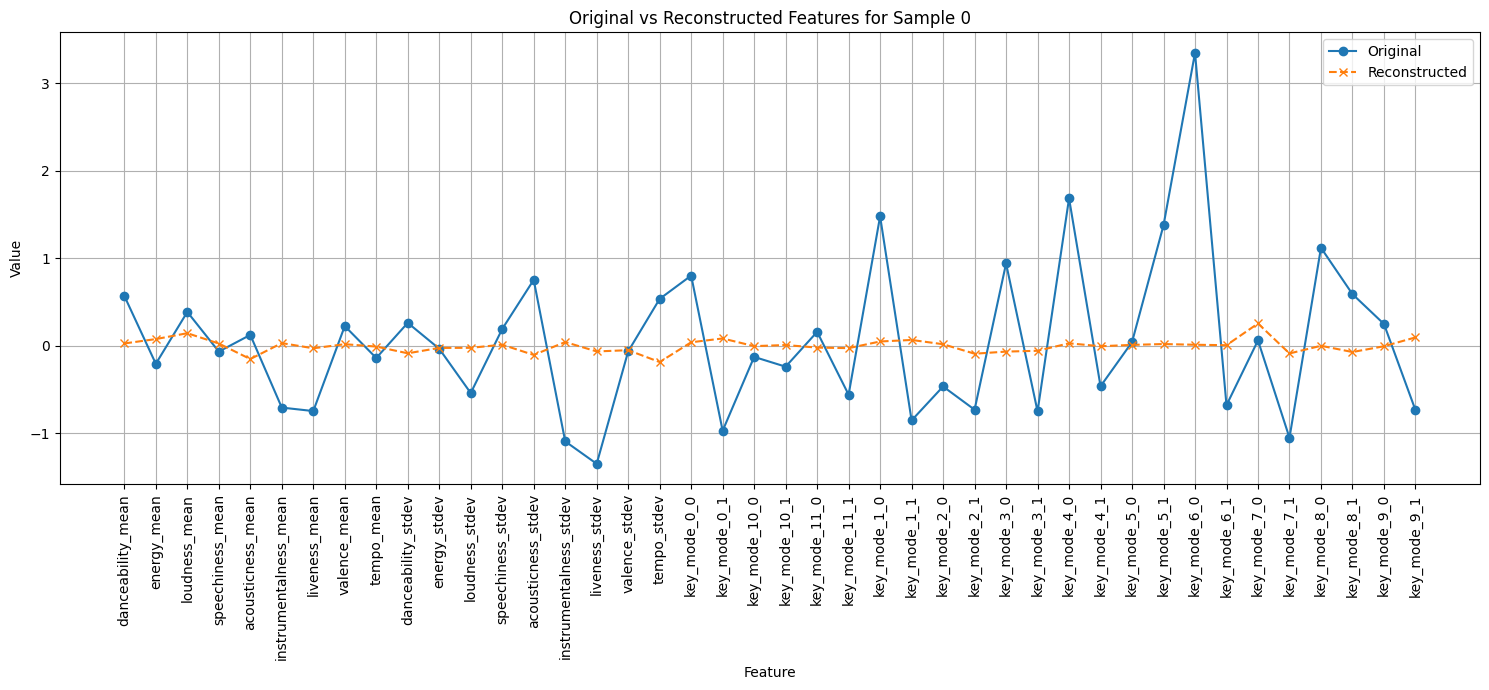

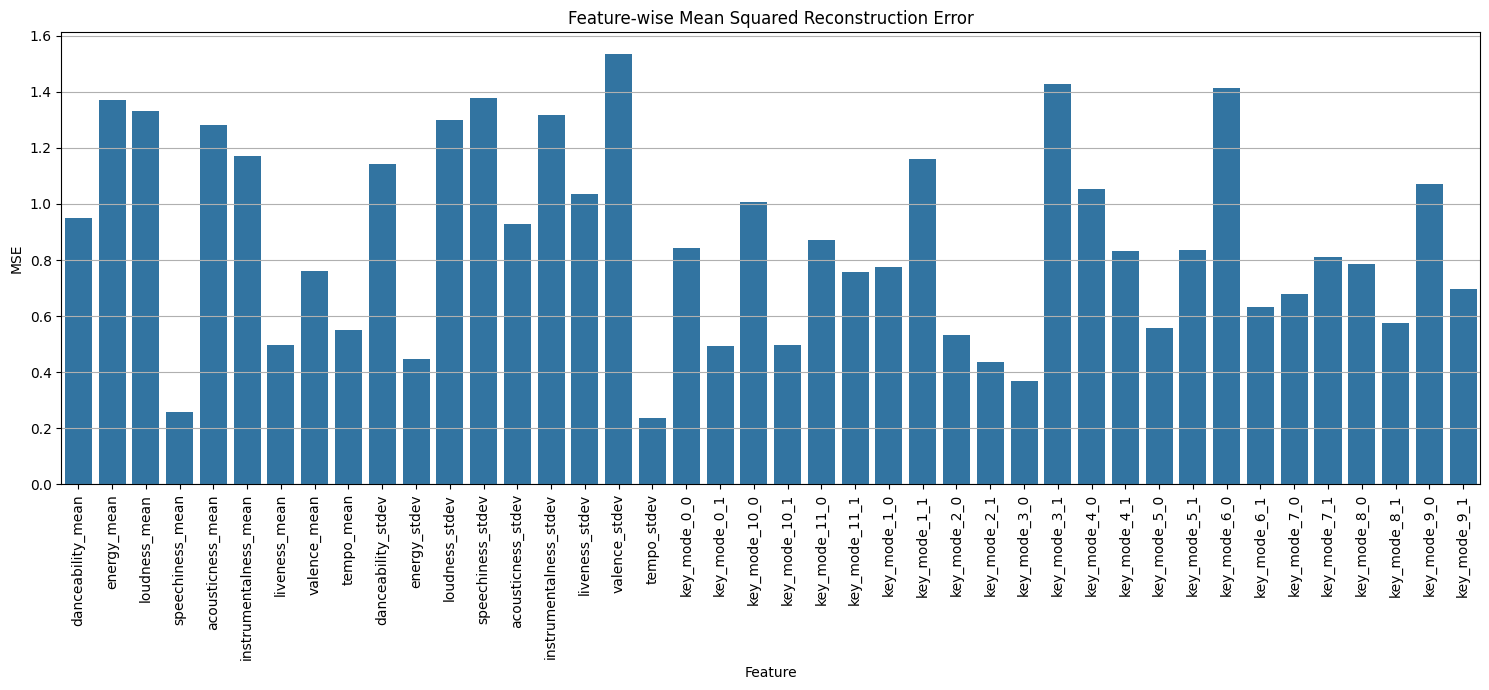

In [18]:
import seaborn as sns

# Visualize Original vs Reconstructed for a sample
sample_idx = 0 # You can change this to look at different samples

original_sample = original_val_inverse[sample_idx]
reconstructed_sample = reconstructed_val_inverse[sample_idx]

# Get feature names for plotting
feature_names_list = feature_names # 'feature_names' is from cell 2

plt.figure(figsize=(15, 7))
plt.plot(feature_names_list, original_sample, label='Original', marker='o')
plt.plot(feature_names_list, reconstructed_sample, label='Reconstructed', marker='x', linestyle='--')
plt.xticks(rotation=90)
plt.title(f'Original vs Reconstructed Features for Sample {sample_idx}')
plt.xlabel('Feature')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Optionally, visualize feature-wise reconstruction error
feature_mse = np.mean(np.square(original_val_inverse - reconstructed_val_inverse), axis=0)

plt.figure(figsize=(15, 7))
sns.barplot(x=feature_names_list, y=feature_mse)
plt.xticks(rotation=90)
plt.title('Feature-wise Mean Squared Reconstruction Error')
plt.xlabel('Feature')
plt.ylabel('MSE')
plt.grid(axis='y')
plt.tight_layout()
plt.show()